### Imports

In [1]:
from fundus_dataset import AugmentPair, FundusVesselDataset, CenterCropPair
from torch.utils.data import DataLoader
import torch.nn as nn
import torch
from topolosses.losses import BettiMatchingLoss
import matplotlib.pyplot as plt
from torch.utils.data import Subset
from monai.networks.nets import UNet
from monai.losses import DiceLoss, SoftclDiceLoss
from safetensors.torch import save_file
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


### Testing the Dataset

In [2]:
img_dir = "fundus/train/Original/"
mask_dir = "fundus/train/Ground truth"

train_full = FundusVesselDataset(
    img_dir=img_dir,
    mask_dir=mask_dir,
    transform=AugmentPair(crop_size=(512, 512)),
)

val_full = FundusVesselDataset(
    img_dir=img_dir,
    mask_dir=mask_dir,
    transform=CenterCropPair(crop_size=(512, 512)),
)

num_samples = len(train_full)
generator = torch.Generator().manual_seed(42)

# Shuffle the indices
indices = torch.randperm(num_samples, generator=generator).tolist()

train_size = int(0.8 * num_samples)

train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(val_full, val_indices)

# Dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=8,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=8,
    pin_memory=torch.cuda.is_available(),
)

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")

images, masks = next(iter(train_loader))
val_images, val_masks = next(iter(val_loader))

print("Train images:", images.shape, images.dtype, images.min().item(), images.max().item())
print("Train masks: ", masks.shape, masks.dtype, torch.unique(masks))

print("Val images:", val_images.shape, val_images.dtype, val_images.min().item(), val_images.max().item())
print("Val masks: ", val_masks.shape, val_masks.dtype, torch.unique(val_masks))

Number of images: 600
Number of masks: 600
First 5 image files:  ['100_A.png', '101_A.png', '102_A.png', '103_A.png', '104_A.png']
First 5 mask files:  ['100_A.png', '101_A.png', '102_A.png', '103_A.png', '104_A.png']
Number of images: 600
Number of masks: 600
First 5 image files:  ['100_A.png', '101_A.png', '102_A.png', '103_A.png', '104_A.png']
First 5 mask files:  ['100_A.png', '101_A.png', '102_A.png', '103_A.png', '104_A.png']
Train size: 480
Val size: 120


Train images: torch.Size([8, 3, 512, 512]) torch.float32 0.0 0.9450980424880981
Train masks:  torch.Size([8, 1, 512, 512]) torch.float32 tensor([0., 1.])
Val images: torch.Size([1, 3, 512, 512]) torch.float32 0.0 1.0
Val masks:  torch.Size([1, 1, 512, 512]) torch.float32 tensor([0., 1.])


### CLDice + BCE + Dice

In [3]:
import numpy as np

class BCEBettiDiceLoss(nn.Module):
    def __init__(self, w_bce=0.5, w_dice=0.5, w_betti=0.001):
        super().__init__()
        self.w_bce = w_bce
        self.w_dice = w_dice
        self.w_betti = w_betti
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss(sigmoid=True)
        self.betti = BettiMatchingLoss(
            alpha=1.0,
            filtration_type="bothlevels",
            num_processes=4,
            push_unmatched_to_1_0=True,
            barcode_length_threshold=0.0,
            topology_weights=(1.0, 1.0),
            sphere=False,
            sigmoid=True,
        )

    def forward(self, logits, masks):
        bce_loss = self.bce(logits, masks)
        dice_loss = self.dice(logits, masks)
        betti_loss = self.betti(logits, masks)

        total = (
            self.w_bce * bce_loss
            + self.w_dice * dice_loss
            + self.w_betti * betti_loss
        )

        return total
        
def hard_dice_score(logits, masks, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    # flatten each image separately: [B, 1, H, W] -> [B, pixels]
    preds = preds.flatten(start_dim=1)
    masks = masks.flatten(start_dim=1)

    intersection = (preds * masks).sum(dim=1)
    denominator = preds.sum(dim=1) + masks.sum(dim=1)

    dice = (2 * intersection + eps) / (denominator + eps)

    return dice.mean()

def hard_cldice_score(logits, masks, threshold=0.5, eps=1e-6):
    del eps  # kept for API parity with hard_dice_score
    from cldice import clDice

    probs = torch.sigmoid(logits)
    preds = (probs > threshold)
    masks = (masks > 0.5)

    # [B, 1, H, W] -> [B, H, W]
    preds = preds.squeeze(1)
    masks = masks.squeeze(1)

    cldice_scores = []
    for pred_i, mask_i in zip(preds, masks):
        pred_np = pred_i.detach().cpu().numpy().astype(np.bool_)
        mask_np = mask_i.detach().cpu().numpy().astype(np.bool_)

        if not pred_np.any() and not mask_np.any():
            score = 1.0
        else:
            score = float(clDice(pred_np, mask_np))
            if not np.isfinite(score):
                score = 0.0

        cldice_scores.append(score)

    if len(cldice_scores) == 0:
        return torch.tensor(0.0, device=logits.device)

    return torch.tensor(sum(cldice_scores) / len(cldice_scores), device=logits.device)


### U-Net Factory

In [4]:
def make_unet(channels=(16, 32, 64, 128, 256)):
    model = UNet(
        spatial_dims=2,
        in_channels=3,
        out_channels=1,
        channels=channels,
        strides=(2, 2, 2, 2),
        num_res_units=2,
    )
    return model.to(device)

### Training Loop Function

In [5]:
def validate_full_image(model, loader, loss_fn, threshold=0.5):
    model.eval()
    val_loss = 0.0
    val_dice = 0.0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            loss = loss_fn(logits, masks)
            dice = hard_dice_score(logits, masks, threshold=threshold)

            val_loss += loss.item() * images.size(0)
            val_dice += dice.item() * images.size(0)

    val_loss /= len(loader.dataset)
    val_dice /= len(loader.dataset)
    return val_loss, val_dice


def train_model(model, train_loader, val_loader, loss_fn, optimizer, epochs, save_path=None, save_name="baseline.safetensors"):
    history = []
    best_val_dice = 0.0
    best_epoch = 0
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_loss_steps = []

        for images, masks in train_loader:
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            logits = model(images)
            loss = loss_fn(logits, masks)

            loss.backward()
            optimizer.step()

            step_loss = loss.item()
            train_loss += step_loss * images.size(0)
            train_loss_steps.append(step_loss)

        train_loss /= len(train_loader.dataset)

        # Default validation protocol: full-image metrics on val_loader.
        val_loss, val_dice = validate_full_image(
            model=model,
            loader=val_loader,
            loss_fn=loss_fn,
            threshold=0.5,
        )

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_loss_steps": train_loss_steps,
            "val_loss": val_loss,
            "val_dice": val_dice,
        })

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            best_epoch = epoch + 1

            if save_path is not None:
                save_dir = Path(save_path)
                save_dir.mkdir(parents=True, exist_ok=True)
                st_path = save_dir / save_name
                save_file(model.state_dict(), st_path)

        print(
            f"Epoch {epoch + 1:03d}/{epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Val loss: {val_loss:.4f} | "
            f"Val Dice: {val_dice:.4f} | "
            f"Best: {best_val_dice:.4f} @ {best_epoch}"
        )

    return history

### DANGEROUS (RESET EXPERIMENT)

In [6]:
model = make_unet(channels=(32, 64, 128, 256, 512))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = BCEBettiDiceLoss(
    w_bce=0.5,
    w_dice=0.5,
    w_betti=1e-5,
)
EPOCHS = 100
SAVE_PATH = "/workspace/models_betti/"
SAVE_NAME = "betti.safetensors"

### START OR CONTINUE EXPERIMENT

In [7]:
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=EPOCHS,
    save_path=SAVE_PATH,
    save_name=SAVE_NAME,
)

/root/Computer-Vision-2026/.venv/lib/python3.12/site-packages/topolosses/losses/betti_matching/src/betti_matching_loss.py:155: UserWarning: Single-channel prediction detected. The `include_background=False` setting  will be ignored.
  warnings.warn(


Epoch 001/100 | Train loss: 1.3690 | Val loss: 1.2678 | Val Dice: 0.2105 | Best: 0.2105 @ 1
Epoch 002/100 | Train loss: 1.1354 | Val loss: 1.0608 | Val Dice: 0.3009 | Best: 0.3009 @ 2
Epoch 003/100 | Train loss: 1.0062 | Val loss: 1.0134 | Val Dice: 0.3798 | Best: 0.3798 @ 3
Epoch 004/100 | Train loss: 0.9250 | Val loss: 0.9883 | Val Dice: 0.4099 | Best: 0.4099 @ 4
Epoch 005/100 | Train loss: 0.8852 | Val loss: 0.9385 | Val Dice: 0.3959 | Best: 0.4099 @ 4
Epoch 006/100 | Train loss: 0.8035 | Val loss: 0.8516 | Val Dice: 0.4856 | Best: 0.4856 @ 6
Epoch 007/100 | Train loss: 0.7970 | Val loss: 0.8533 | Val Dice: 0.4791 | Best: 0.4856 @ 6
Epoch 008/100 | Train loss: 0.7645 | Val loss: 0.8235 | Val Dice: 0.5575 | Best: 0.5575 @ 8
Epoch 009/100 | Train loss: 0.7213 | Val loss: 0.7651 | Val Dice: 0.5906 | Best: 0.5906 @ 9
Epoch 010/100 | Train loss: 0.7079 | Val loss: 0.7698 | Val Dice: 0.6009 | Best: 0.6009 @ 10
Epoch 011/100 | Train loss: 0.6768 | Val loss: 0.8258 | Val Dice: 0.5716 | Best

### Save your Settings

In [8]:
import pandas as pd

history_df = pd.DataFrame(history)
history_df.to_csv("/workspace/models_betti/betti_history.csv", index=False)

### Training Graphs

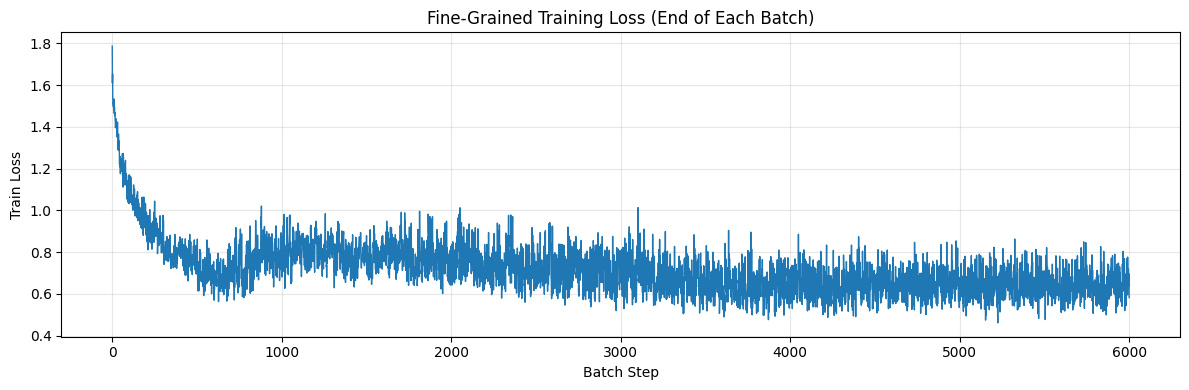

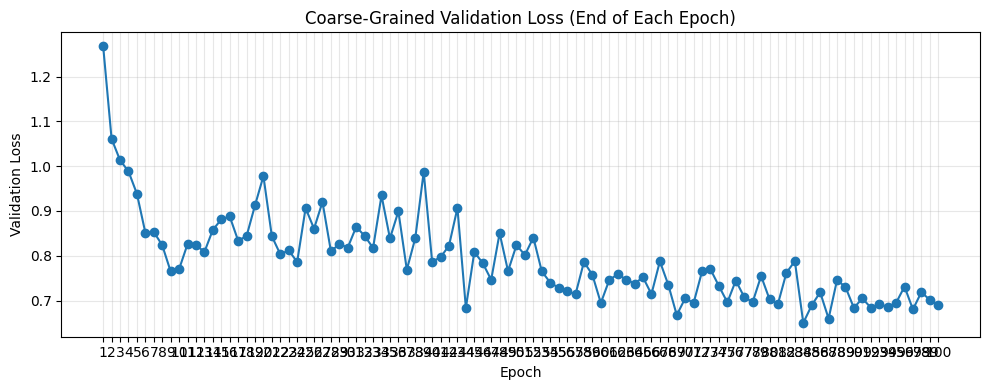

Loaded 100 epochs from /workspace/models_betti/betti_history.csv
Plotted 6000 batch-level training-loss points


In [9]:
import ast
import pandas as pd
import matplotlib.pyplot as plt

history_csv = "/workspace/models_betti/betti_history.csv"
history_df = pd.read_csv(history_csv)

required_cols = {"epoch", "train_loss_steps", "val_loss"}
missing_cols = required_cols - set(history_df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns in {history_csv}: {sorted(missing_cols)}")

# Parse stringified step-loss lists safely.
train_loss_steps_per_epoch = history_df["train_loss_steps"].apply(ast.literal_eval)

batch_steps = []
train_step_losses = []
step_idx = 1

for epoch_steps in train_loss_steps_per_epoch:
    batch_steps.extend(range(step_idx, step_idx + len(epoch_steps)))
    train_step_losses.extend(epoch_steps)
    step_idx += len(epoch_steps)

plt.figure(figsize=(12, 4))
plt.plot(batch_steps, train_step_losses, linewidth=1)
plt.title("Fine-Grained Training Loss (End of Each Batch)")
plt.xlabel("Batch Step")
plt.ylabel("Train Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", linewidth=1.5)
plt.title("Coarse-Grained Validation Loss (End of Each Epoch)")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.xticks(history_df["epoch"])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Loaded {len(history_df)} epochs from {history_csv}")
print(f"Plotted {len(train_step_losses)} batch-level training-loss points")

### Hard Evaluation Functions

Here we load a model safetensors file and then perform inference on it. We will evaluate on the following metrics:


1. Binary Statistics (Dice, IoU, Precision, Recall, F1)
2. $B_0$ and $B_1$ topological errors

In [10]:
import torch


def binary_segmentation_metrics(y_true: torch.Tensor, y_pred: torch.Tensor, threshold: float = 0.5, eps: float = 1e-7):
    """
    Compute Dice, IoU, precision, recall, and F1 for binary segmentation.
    """

    # We need to detach the tensors to avoid gradient computation
    y_true = y_true.detach()
    y_pred = y_pred.detach()

    # Threshold the predictions
    y_true = (y_true > 0.5).float()
    y_pred = (y_pred > threshold).float()

    # This gives 1D vectors
    y_true = y_true.view(-1)
    y_pred = y_pred.view(-1)

    tp = torch.sum((y_pred == 1) & (y_true == 1)).float()
    fp = torch.sum((y_pred == 1) & (y_true == 0)).float()
    fn = torch.sum((y_pred == 0) & (y_true == 1)).float()
    tn = torch.sum((y_pred == 0) & (y_true == 0)).float()

    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)
    f1 = (2 * precision * recall + eps) / (precision + recall + eps)  # This is literally the same as Dice, but we'll keep it for clarity

    return {
        "dice": dice.item(),
        "iou": iou.item(),
        "precision": precision.item(),
        "recall": recall.item(),
        "f1": f1.item(),
        "tp": tp.item(),
        "fp": fp.item(),
        "fn": fn.item(),
        "tn": tn.item(),
    }

In [11]:
import torch
import numpy as np
from scipy import ndimage


def beta0_beta1_2d(binary_mask: np.ndarray):
    """
    Computes Betti numbers for a 2D binary mask. 

    b_0 is the number of connected foreground components
    b_1 is the number of enclosed background holes inside foreground
    """
    binary_mask = binary_mask.astype(bool)

    # Foreground connectivity.
    # 4-connectivity is conservative for thin structures.
    fg_structure = ndimage.generate_binary_structure(2, 1)
    _, beta0 = ndimage.label(binary_mask, structure=fg_structure)

    # Background components.
    # Holes are background components that do NOT touch the image border.
    background = ~binary_mask

    # 8-connectivity for background is often paired with 4-connectivity foreground
    # to avoid ambiguous diagonal connections.
    bg_structure = ndimage.generate_binary_structure(2, 2)
    bg_labels, num_bg = ndimage.label(background, structure=bg_structure)

    if num_bg == 0:
        beta1 = 0
        return beta0, beta1

    border_labels = set()

    border_labels.update(np.unique(bg_labels[0, :]))
    border_labels.update(np.unique(bg_labels[-1, :]))
    border_labels.update(np.unique(bg_labels[:, 0]))
    border_labels.update(np.unique(bg_labels[:, -1]))

    # Label 0 is not a real component.
    border_labels.discard(0)

    all_bg_labels = set(range(1, num_bg + 1))
    hole_labels = all_bg_labels - border_labels

    beta1 = len(hole_labels)

    return beta0, beta1

def betti_error_one_image(
    logits: torch.Tensor,
    mask: torch.Tensor,
    threshold: float = 0.5,
    b0_weight: float = 1.0,
    b1_weight: float = 1.0,
):
    """
    Computes non-differentiable Betti error for one predicted mask and one GT mask.

    Args:
        logits: [1, H, W] or [H, W], raw model output for one image
        mask:   [1, H, W] or [H, W], binary ground truth mask
        threshold: probability threshold for binarizing prediction
        b0_weight: weight for beta0 error
        b1_weight: weight for beta1 error

    Returns:
        loss: scalar torch.Tensor, useful for logging
        stats: dict with Betti numbers and errors for this image
    """
    probs = torch.sigmoid(logits)
    pred = (probs > threshold).float()

    pred_np = pred.detach().cpu().numpy()
    mask_np = mask.detach().cpu().numpy()

    # Remove channel dimension if present: [1, H, W] -> [H, W]
    if pred_np.ndim == 3: pred_np = pred_np[0]

    if mask_np.ndim == 3: mask_np = mask_np[0]

    b0_pred, b1_pred = beta0_beta1_2d(pred_np)
    b0_gt, b1_gt = beta0_beta1_2d(mask_np)

    b0_error = abs(b0_pred - b0_gt)
    b1_error = abs(b1_pred - b1_gt)

    total_error = b0_weight * b0_error + b1_weight * b1_error

    loss = torch.tensor(total_error, device=logits.device, dtype=logits.dtype)

    stats = {
        "betti_loss": float(total_error),
        "b0_error": b0_error,
        "b1_error": b1_error,
        "betti_error": b0_error + b1_error,
        "b0_pred": b0_pred,
        "b1_pred": b1_pred,
        "b0_gt": b0_gt,
        "b1_gt": b1_gt,
    }

    return loss, stats

### Firm Evaluation Functions

The hard versions of the Losses: clDice, Skeleton Recall, cbDice

### Perform Evaluation

In [12]:
from statistics import mean

import torch
from torch.utils.data import DataLoader
from safetensors.torch import load_file

test_ds = FundusVesselDataset(
    img_dir="fundus/test/Original/",
    mask_dir="fundus/test/Ground truth",
    transform=None,
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=4,
    pin_memory=torch.cuda.is_available(),
)

eval_model = make_unet(channels=(32, 64, 128, 256, 512)).to(device)
eval_model.load_state_dict(load_file("/workspace/models_betti/betti.safetensors"))
eval_model.eval()


rows = []

with torch.no_grad():
    for idx, (images, masks) in enumerate(test_loader):
        name = test_ds.images[idx]

        images = images.to(device)
        masks = masks.to(device)

        logits = eval_model(images)
        probs = torch.sigmoid(logits)

        _, betti_stats = betti_error_one_image(logits[0], masks[0], threshold=0.5, b0_weight=1.0, b1_weight=1.0)

        hard_cldice = hard_cldice_score(logits, masks, threshold=0.5).item()

        row = {
            "image": name,
            **binary_segmentation_metrics(masks, probs, threshold=0.5),
            **betti_stats,
            "hard_cldice": hard_cldice,
        }
        rows.append(row)


# -----------------------
# Print mean results
# -----------------------

binary_keys = ["dice", "iou", "precision", "recall", "f1"]
betti_keys = ["b0_error", "b1_error", "betti_error"]

print("Mean binary metrics:")
for key in binary_keys:
    print(f"  {key}: {mean(row[key] for row in rows):.6f}")

print("\nMean Betti / topological errors:")
for key in betti_keys:
    print(f"  {key}: {mean(row[key] for row in rows):.6f}")

cldice_keys = ["hard_cldice"]

print("\nMean clDice (hard):")
for key in cldice_keys:
    print(f"  {key}: {mean(row[key] for row in rows):.6f}")

Number of images: 200
Number of masks: 200
First 5 image files:  ['100_D.png', '101_G.png', '102_G.png', '103_G.png', '104_G.png']
First 5 mask files:  ['100_D.png', '101_G.png', '102_G.png', '103_G.png', '104_G.png']


Mean binary metrics:
  dice: 0.877534
  iou: 0.792000
  precision: 0.889533
  recall: 0.869405
  f1: 0.877534

Mean Betti / topological errors:
  b0_error: 72.745000
  b1_error: 10.400000
  betti_error: 83.145000

Mean clDice (hard):
  hard_cldice: 0.884304


### Top 5 Worst $B_0$

$B_0$ counts how many connected components the segmented foreground (vessels) has under 4-connectivity.

    image  b0_gt  b0_pred  b0_error  b1_error     dice
154_N.png     18      199       181         8 0.724450
177_N.png     15      194       179         0 0.883943
178_N.png     14      188       174         6 0.866272
188_N.png      9      174       165         7 0.886159
152_N.png      8      171       163        21 0.862722


/tmp/ipykernel_419528/377410309.py:38: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  return binary_dilation(


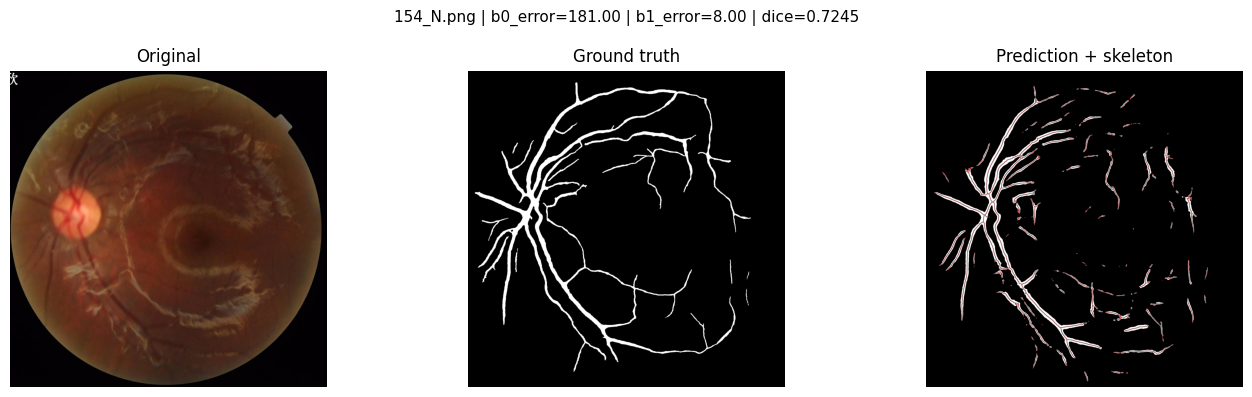

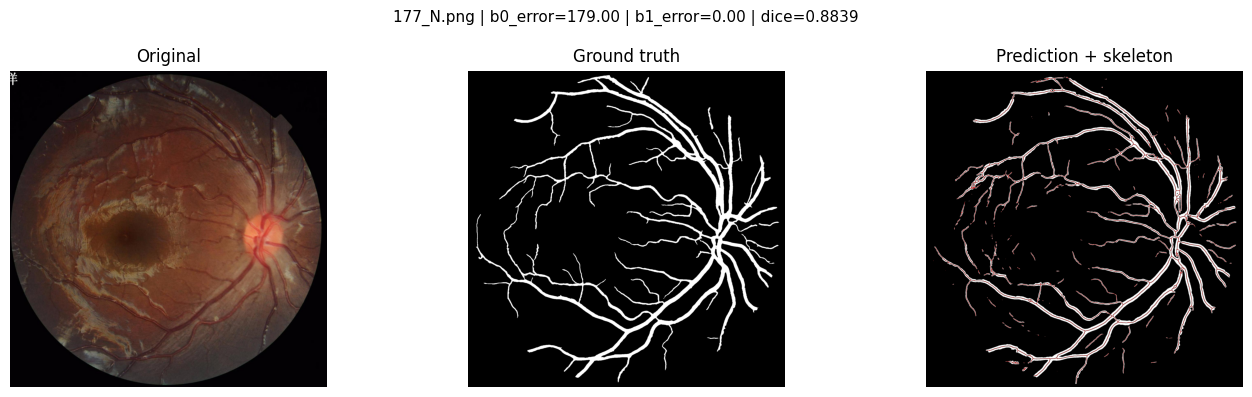

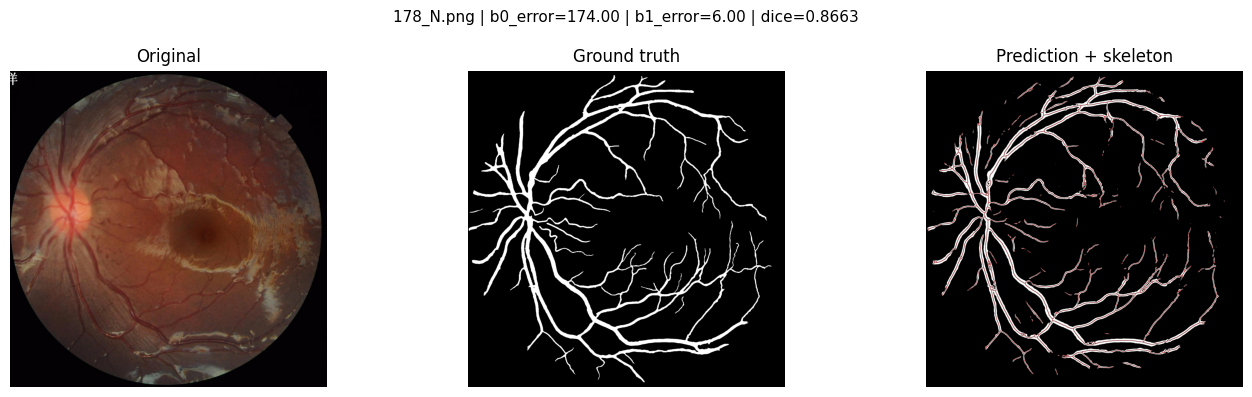

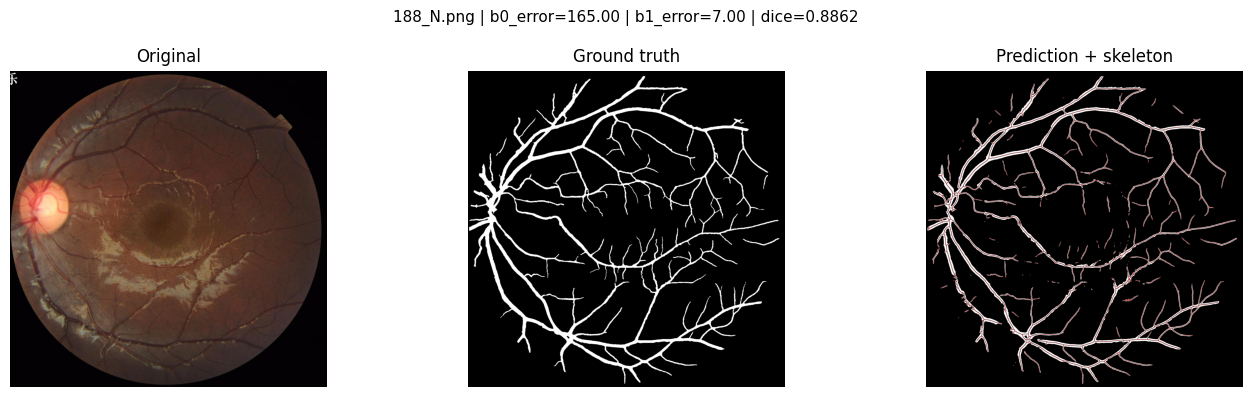

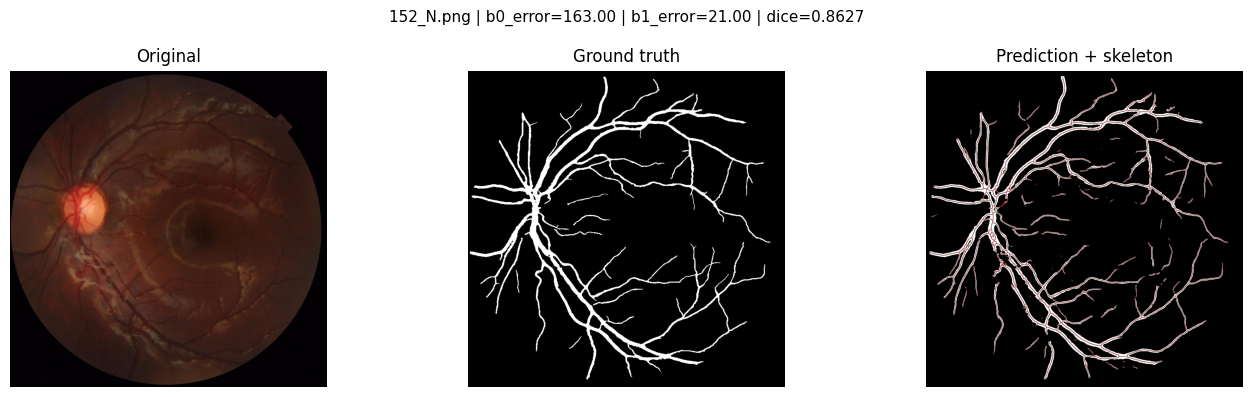

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from skimage.morphology import skeletonize, binary_dilation


# -----------------------
# Find worst 5 by B0 error
# -----------------------

top5_b0 = sorted(rows, key=lambda r: r["b0_error"], reverse=True)[:5]

summary = pd.DataFrame(top5_b0)[
    ["image", "b0_gt", "b0_pred", "b0_error", "b1_error", "dice"]
]

print(summary.to_string(index=False))


# -----------------------
# Helpers
# -----------------------

def predict_mask(model, image, threshold=0.5):
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(image)
        probs = torch.sigmoid(logits)

    return (probs > threshold).cpu().numpy()[0, 0]


def make_skeleton_overlay(pred_mask):
    skeleton = skeletonize(pred_mask > 0)
    return binary_dilation(
        skeleton,
        footprint=np.ones((3, 3), dtype=bool),
    )


def show_b0_example(row):
    image_name = row["image"]
    idx = test_ds.images.index(image_name)

    image, mask = test_ds[idx]

    pred_mask = predict_mask(eval_model, image)
    skeleton_overlay = make_skeleton_overlay(pred_mask)

    original = image.numpy().transpose(1, 2, 0)
    gt_mask = mask.numpy()[0]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].imshow(np.clip(original, 0.0, 1.0))
    axes[0].set_title("Original")

    axes[1].imshow(gt_mask, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Ground truth")

    axes[2].imshow(pred_mask, cmap="gray", vmin=0, vmax=1)
    axes[2].imshow(
        np.ma.masked_where(~skeleton_overlay, skeleton_overlay),
        cmap="autumn",
        alpha=0.95,
    )
    axes[2].set_title("Prediction + skeleton")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(
        f"{image_name} | "
        f"b0_error={row['b0_error']:.2f} | "
        f"b1_error={row['b1_error']:.2f} | "
        f"dice={row['dice']:.4f}",
        fontsize=11,
    )

    plt.tight_layout()
    plt.show()


# -----------------------
# Plot worst examples
# -----------------------

eval_model.eval()

for row in top5_b0:
    show_b0_example(row)

### Top 5 Worst $B_1$

$B_1$ counts holes: background regions fully enclosed by foreground (8-connected background, ignoring components that touch the image border).

    image  b1_gt  b1_pred  b1_error  b0_error     dice
 62_D.png     79        9        70        59 0.747565
 91_D.png     79       21        58       108 0.863490
126_G.png     63        7        56        43 0.916065
137_G.png     33        0        33        51 0.747063
103_G.png     37       10        27        23 0.839413


/tmp/ipykernel_419528/3990854543.py:41: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  return binary_dilation(


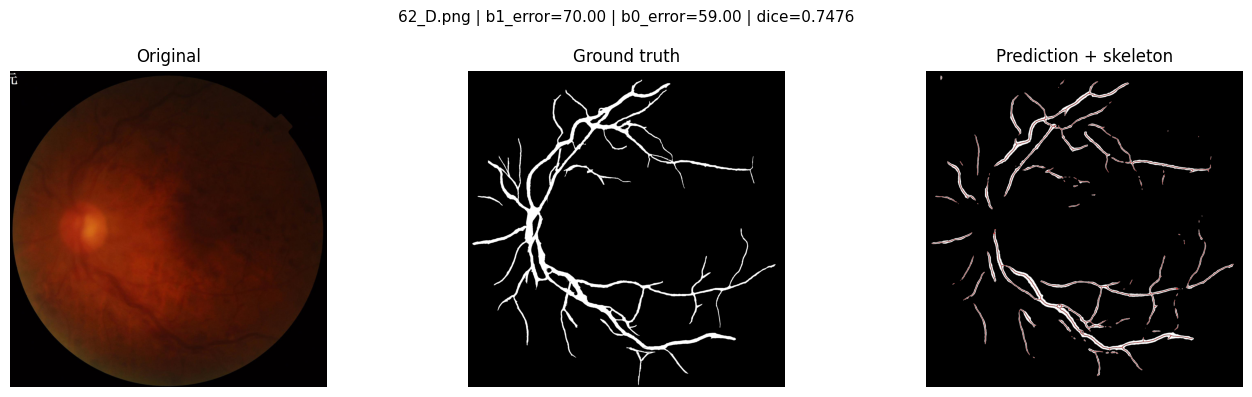

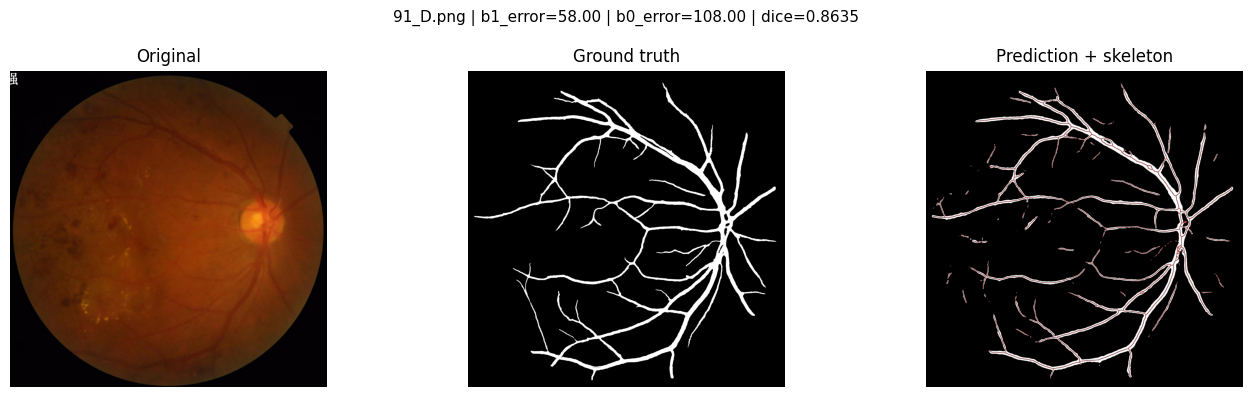

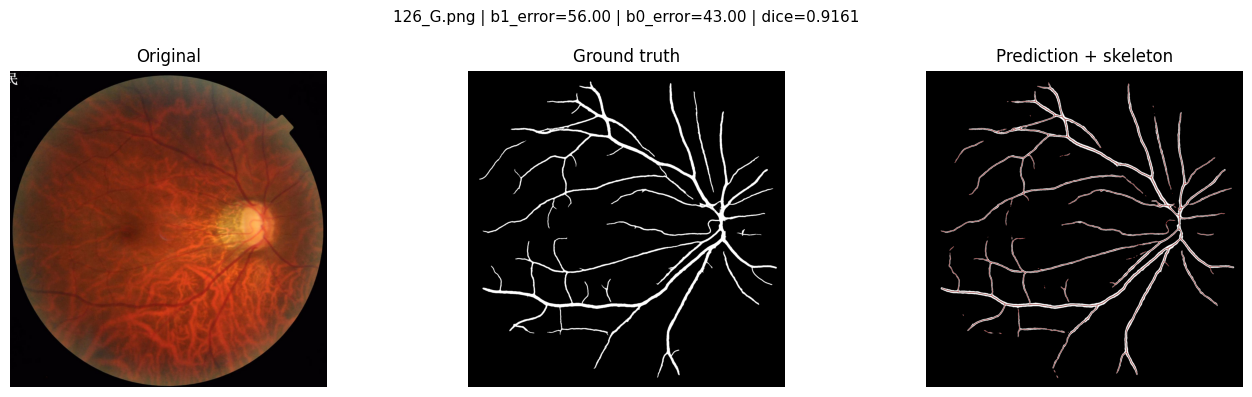

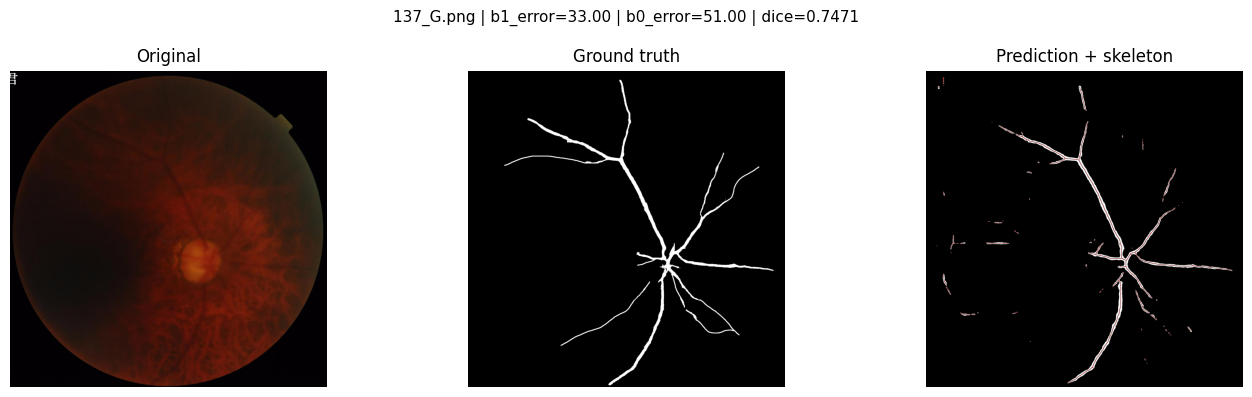

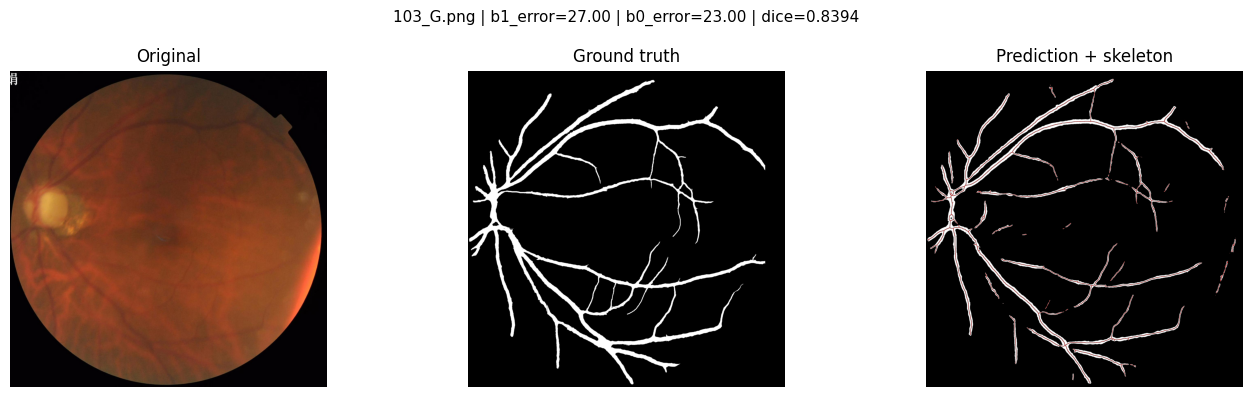

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from skimage.morphology import skeletonize, binary_dilation


# -----------------------
# Find worst 5 by B1 error
# -----------------------

top5_b1 = sorted(rows, key=lambda r: r["b1_error"], reverse=True)[:5]

summary = pd.DataFrame(top5_b1)[
    ["image", "b1_gt", "b1_pred", "b1_error", "b0_error", "dice"]
]

print(summary.to_string(index=False))


# -----------------------
# Helpers
# -----------------------

name_to_idx = {name: idx for idx, name in enumerate(test_ds.images)}


def predict_mask(model, image, threshold=0.5):
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(image)
        probs = torch.sigmoid(logits)

    return (probs > threshold).cpu().numpy()[0, 0]


def make_skeleton_overlay(pred_mask):
    skeleton = skeletonize(pred_mask > 0)
    return binary_dilation(
        skeleton,
        footprint=np.ones((3, 3), dtype=bool),
    )


def show_b1_example(row):
    image_name = row["image"]
    idx = name_to_idx[image_name]

    image, mask = test_ds[idx]

    pred_mask = predict_mask(eval_model, image)
    skeleton_overlay = make_skeleton_overlay(pred_mask)

    original = image.numpy().transpose(1, 2, 0)
    gt_mask = mask.numpy()[0]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].imshow(np.clip(original, 0.0, 1.0))
    axes[0].set_title("Original")

    axes[1].imshow(gt_mask, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Ground truth")

    axes[2].imshow(pred_mask, cmap="gray", vmin=0, vmax=1)
    axes[2].imshow(
        np.ma.masked_where(~skeleton_overlay, skeleton_overlay),
        cmap="autumn",
        alpha=0.95,
    )
    axes[2].set_title("Prediction + skeleton")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(
        f"{image_name} | "
        f"b1_error={row['b1_error']:.2f} | "
        f"b0_error={row['b0_error']:.2f} | "
        f"dice={row['dice']:.4f}",
        fontsize=11,
    )

    plt.tight_layout()
    plt.show()


# -----------------------
# Plot worst examples
# -----------------------

eval_model.eval()

for row in top5_b1:
    show_b1_example(row)

### Top 5 Best clDice

Highest hard clDice values on the test set (best per-image topological overlap).

    image  hard_cldice     dice  b0_error  b1_error  betti_error
 13_A.png     0.966293 0.945821        28         4           32
 48_A.png     0.961927 0.946883        51         6           57
131_G.png     0.961724 0.946545        44         4           48
 14_A.png     0.961625 0.945118        50         7           57
 32_A.png     0.961206 0.945099        51         9           60


/tmp/ipykernel_419528/1539098241.py:41: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  return binary_dilation(


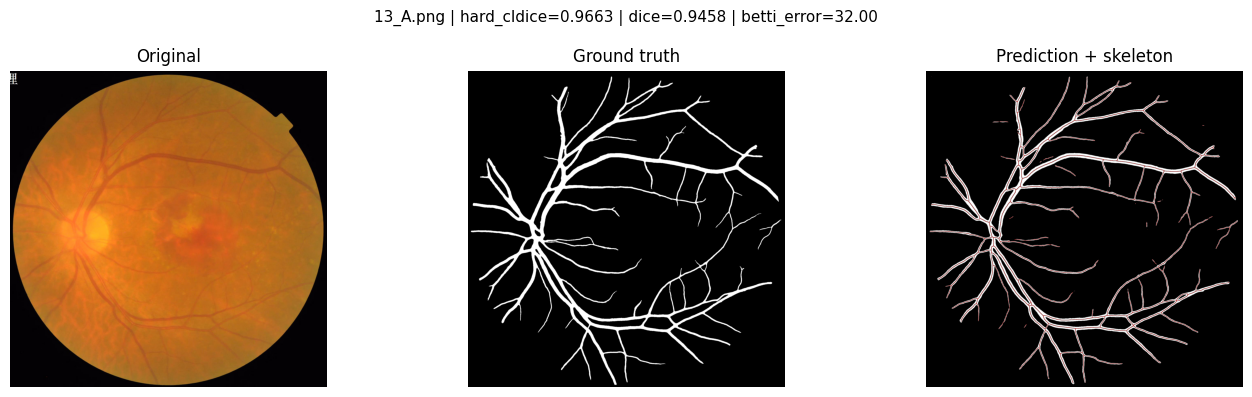

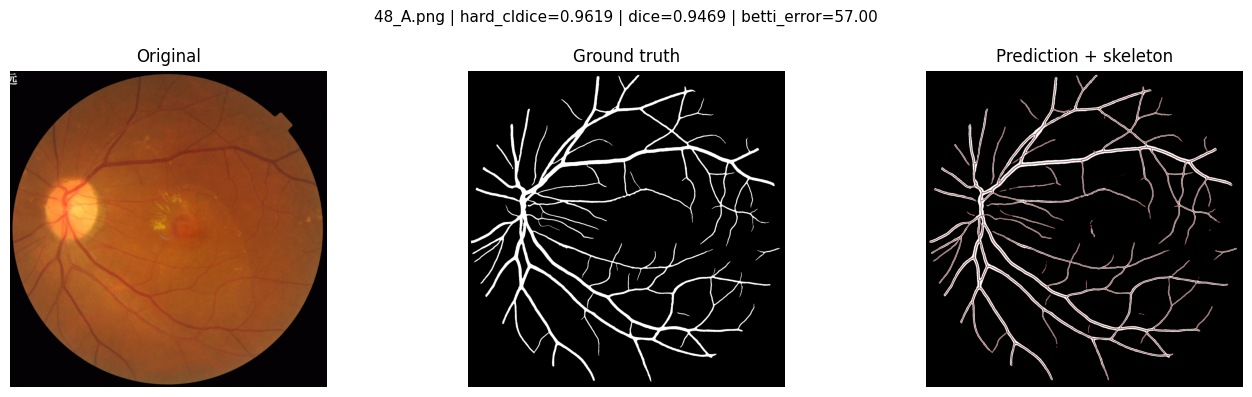

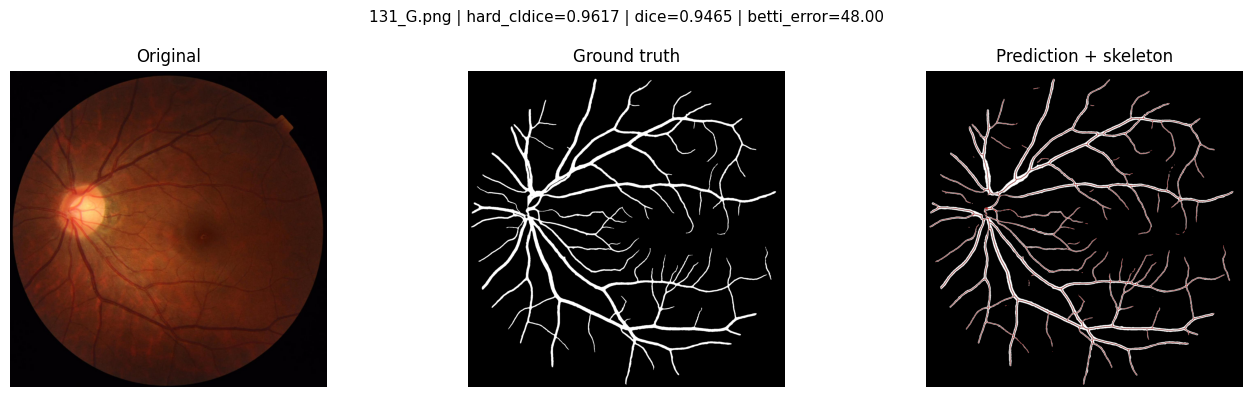

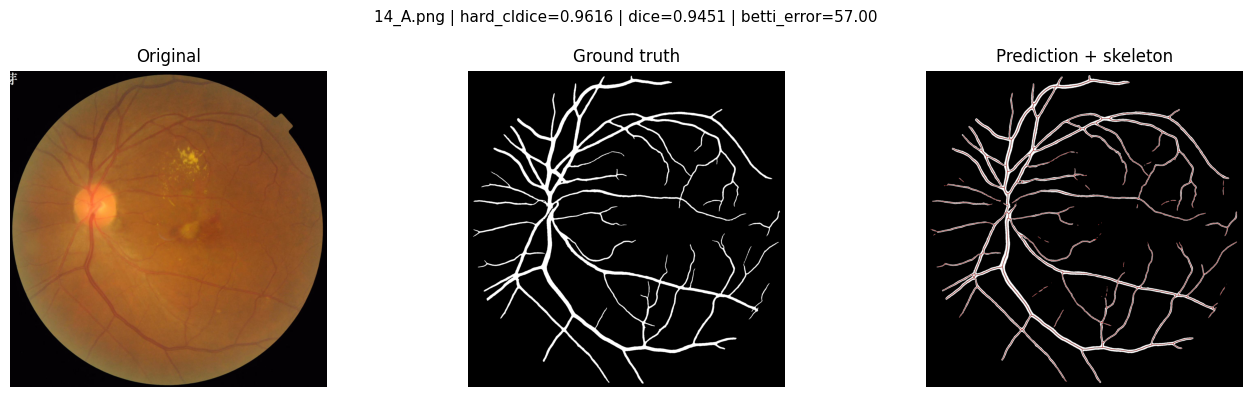

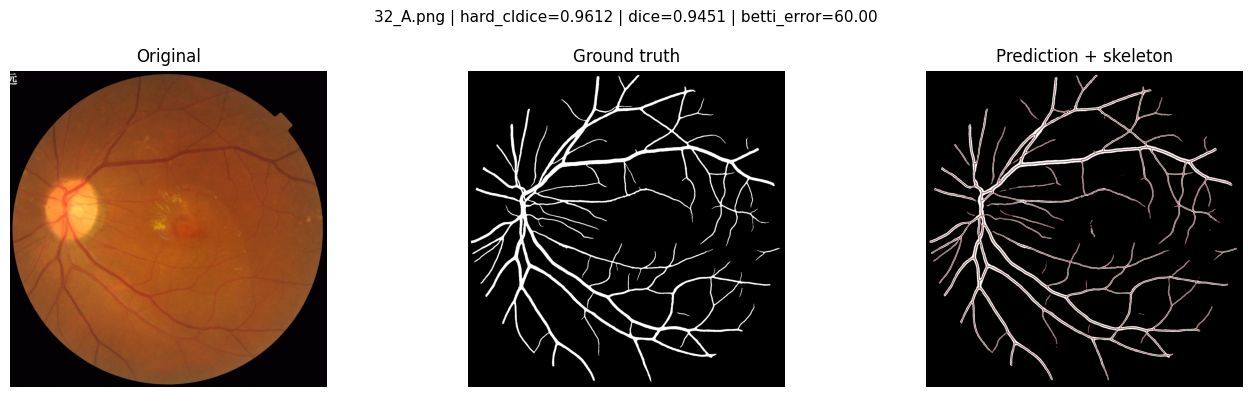

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from skimage.morphology import skeletonize, binary_dilation


# -----------------------
# Find best 5 by hard clDice
# -----------------------

top5_cldice = sorted(rows, key=lambda r: r["hard_cldice"], reverse=True)[:5]

summary = pd.DataFrame(top5_cldice)[
    ["image", "hard_cldice", "dice", "b0_error", "b1_error", "betti_error"]
]

print(summary.to_string(index=False))


# -----------------------
# Helpers
# -----------------------

name_to_idx = {name: idx for idx, name in enumerate(test_ds.images)}


def predict_mask(model, image, threshold=0.5):
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(image)
        probs = torch.sigmoid(logits)

    return (probs > threshold).cpu().numpy()[0, 0]


def make_skeleton_overlay(pred_mask):
    skeleton = skeletonize(pred_mask > 0)
    return binary_dilation(
        skeleton,
        footprint=np.ones((3, 3), dtype=bool),
    )


def show_cldice_example(row):
    image_name = row["image"]
    idx = name_to_idx[image_name]

    image, mask = test_ds[idx]

    pred_mask = predict_mask(eval_model, image)
    skeleton_overlay = make_skeleton_overlay(pred_mask)

    original = image.numpy().transpose(1, 2, 0)
    gt_mask = mask.numpy()[0]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].imshow(np.clip(original, 0.0, 1.0))
    axes[0].set_title("Original")

    axes[1].imshow(gt_mask, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Ground truth")

    axes[2].imshow(pred_mask, cmap="gray", vmin=0, vmax=1)
    axes[2].imshow(
        np.ma.masked_where(~skeleton_overlay, skeleton_overlay),
        cmap="autumn",
        alpha=0.95,
    )
    axes[2].set_title("Prediction + skeleton")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(
        f"{image_name} | "
        f"hard_cldice={row['hard_cldice']:.4f} | "
        f"dice={row['dice']:.4f} | "
        f"betti_error={row['betti_error']:.2f}",
        fontsize=11,
    )

    plt.tight_layout()
    plt.show()


# -----------------------
# Plot best examples
# -----------------------

eval_model.eval()

for row in top5_cldice:
    show_cldice_example(row)